# Creating event dataset for scenario reconstruction from CICIDS2017

## 1.1 - Preliminary actions

### 1.1.1 - Validate downloaded files

In [1]:
import os
print(os.getcwd())
for root, dirs, files in os.walk('./CSVs'):
        print(root+":")
        if dirs:
            print('\n'.join(dirs))
        if files:
            print('\n'.join(files))

/home/users/davide.zhang/Attack Scenario Reconstruction
./CSVs:
.ipynb_checkpoints
merged
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
./CSVs/.ipynb_checkpoints:
Wednesday-workingHours.pcap_ISCX-checkpoint.csv
./CSVs/merged:
.ipynb_checkpoints
Train.csv
Test.csv
Rec_dataset.csv
./CSVs/merged/.ipynb_checkpoints:
Rec_dataset-checkpoint.csv


### 1.1.2 - Inspect csv file columns

In [2]:
import csv

files=os.listdir('./CSVs')
for file in files:
    if file.endswith(".csv"):
        print("\n"+file+"\n")
        with open(f"./CSVs/{file}", newline="") as f:
            r=csv.DictReader(f)
            print('\n'.join(name.strip() for name in r.fieldnames))


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Flow ID
Source IP
Source Port
Destination IP
Destination Port
Protocol
Timestamp
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Av

### 1.1.3 - Dataframe merging 

In [3]:
import pandas as pd

df_list=[]
for file in files:
    if file.endswith(".csv"):
       df_list.append(pd.read_csv(f"./CSVs/{file}", encoding="latin-1"))
df=pd.concat(df_list)

/tmp/ipykernel_641763/3528085548.py:6: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(f"./CSVs/{file}", encoding="latin-1"))


### 1.1.4 - Dataset cleaning

In [4]:
import numpy as np

df.columns = df.columns.str.strip()
df = df.dropna(how='all')
df.info()
print()
print(df['Label'].value_counts())
df=df.replace([np.inf, -np.inf, np.nan], -1)

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      str    
 1   Source IP                    str    
 2   Source Port                  float64
 3   Destination IP               str    
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    str    
 7   Flow Duration                float64
 8   Total Fwd Packets            float64
 9   Total Backward Packets       float64
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  Bwd Packet Length

### 1.1.5 - Attack type-based train-test splitting

In [5]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], dayfirst=True, format='mixed')
df = df.sort_values("Timestamp").reset_index(drop=True)

In [6]:
train_parts=[]
test_parts=[]
for label, group in df.groupby("Label", sort=False):
    group = group.sort_values("Timestamp")
    split_idx = int(len(group) * 0.67)
    split_idx = max(1, min(split_idx, len(group) - 1))
    train_parts.append(group.iloc[:split_idx])
    test_parts.append(group.iloc[split_idx:])

In [7]:
train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)
train_df.info()
test_df.info()
print("Train label distribution:")
print(train_df['Label'].value_counts())
print("Test label distribution:")
print(test_df['Label'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 85 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   Flow ID                      str           
 1   Source IP                    str           
 2   Source Port                  float64       
 3   Destination IP               str           
 4   Destination Port             float64       
 5   Protocol                     float64       
 6   Timestamp                    datetime64[us]
 7   Flow Duration                float64       
 8   Total Fwd Packets            float64       
 9   Total Backward Packets       float64       
 10  Total Length of Fwd Packets  float64       
 11  Total Length of Bwd Packets  float64       
 12  Fwd Packet Length Max        float64       
 13  Fwd Packet Length Min        float64       
 14  Fwd Packet Length Mean       float64       
 15  Fwd Packet Length Std        float64       
 16  Bwd Packet 

### 1.1.6 - Saving train-set and test-set

In [8]:
train_df.to_csv("./CSVs/merged/Train.csv",index=False)
test_df.to_csv("./CSVs/merged/Test.csv",index=False)

## 1.2 - Computing anomaly score

### 1.2.1 - Loading the datasets

In [9]:
import numpy as np
import pandas as pd
df_train=pd.read_csv("./CSVs/merged/Train.csv")
df_test=pd.read_csv("./CSVs/merged/Test.csv")

### 1.2.2 - Categorical encoding for anomaly detection

In [10]:
def label_encode(dataframe, tags):
    dataframe=dataframe.copy()
    dataframe['Label'] = dataframe['Label'].isin(tags).astype(int)
    return dataframe

In [11]:
df_train=label_encode(df_train, ['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack \x96 Brute Force', 'Web Attack \x96 XSS', 'Infiltration', 'Web Attack \x96 Sql Injection', 'Heartbleed'])
df_test=label_encode(df_test, ['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack \x96 Brute Force', 'Web Attack \x96 XSS', 'Infiltration', 'Web Attack \x96 Sql Injection', 'Heartbleed'])

### 1.2.3 - Feature removal

In [12]:
rm_cols=["Flow ID", "Source IP", "Destination IP", "Timestamp"]
df_train = df_train.drop(rm_cols, axis=1)
df_test = df_test.drop(rm_cols, axis=1)

### 1.2.4 - Feature label separation

In [13]:
y_train, X_train= df_train["Label"], df_train.drop("Label", axis=1)
y_test, X_test= df_test["Label"], df_test.drop("Label", axis=1)
X_train.info()
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  Flow IAT St

### 1.2.5 - Standardization

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### 1.2.6 - Computing contamination

In [15]:
print("contamination: ")
print(y_train.value_counts().get(1)/len(y_train))

contamination: 
0.19699397497931814


### 1.2.7 - Train anomaly detectors

In [16]:
from pyod.models.iforest import IForest
iforest=IForest(contamination=0.2, n_estimators=500,  n_jobs=10, random_state=42)
iforest.fit(X_train)

,n_estimators,500
,max_samples,'auto'
,contamination,0.2
,max_features,1.0
,bootstrap,False
,n_jobs,10
,behaviour,'old'
,random_state,42
,verbose,0


In [17]:
from pyod.models.hbos import HBOS
hbos=HBOS(n_bins=500, contamination=0.2)
hbos.fit(X_train)

,n_bins,500
,alpha,0.1
,tol,0.5
,contamination,0.2


In [18]:
from pyod.models.sampling import Sampling
sampling=Sampling(contamination=0.2, subset_size=200, random_state=42)
sampling.fit(X_train)

,contamination,0.2
,subset_size,200
,metric,'minkowski'
,metric_params,None
,random_state,RandomState(M...0x7F0BD4511840


In [19]:
from sklearn.naive_bayes import GaussianNB
naive_bayes=GaussianNB()
naive_bayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [20]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis(reg_param=1.0)
qda.fit(X_train, y_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",1.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [21]:
from sklearn.linear_model import LogisticRegression
logistic_regression=LogisticRegression(max_iter=500, random_state=42)
logistic_regression.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=50, random_state=42)
xgb.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

### 1.2.8 - Test anomaly detection function definition

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
def evaluate_metrics(predictor, name):
    y_pred=predictor.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    print(f"{name} test accuracy: {acc:.3f}")
    rec=recall_score(y_test, y_pred)
    print(f"{name} test recall: {rec:.3f}")
    prec=precision_score(y_test, y_pred)
    print(f"{name} test precision: {prec:.3f}")

### 1.2.9 - ROC and Precision-Recall Functions definition

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
def show_roc(predictor, name):
    y_prob=predictor.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name=name)
    displ.plot()
    plt.show()

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt
def show_prc(predictor, name):
    y_prob=predictor.predict_proba(X_test)[:,1]
    pre, rec, _ = precision_recall_curve(y_test, y_prob)
    avg_pre = average_precision_score(y_test, y_prob)
    disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, name=name)
    disp.plot()
    plt.show()

### 1.2.10 - Test anomaly detectors

In [26]:
evaluate_metrics(iforest, "IForest")

IForest test accuracy: 0.755
IForest test recall: 0.366
IForest test precision: 0.375


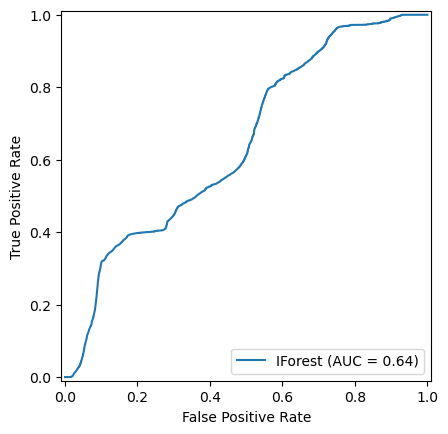

In [27]:
show_roc(iforest, "IForest")

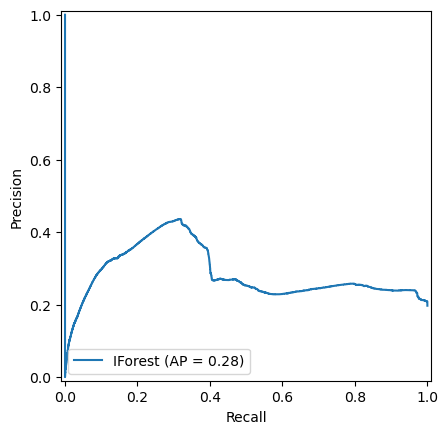

In [28]:
show_prc(iforest, "IForest")

In [29]:
evaluate_metrics(hbos, "HBOS")

HBOS test accuracy: 0.724
HBOS test recall: 0.281
HBOS test precision: 0.292


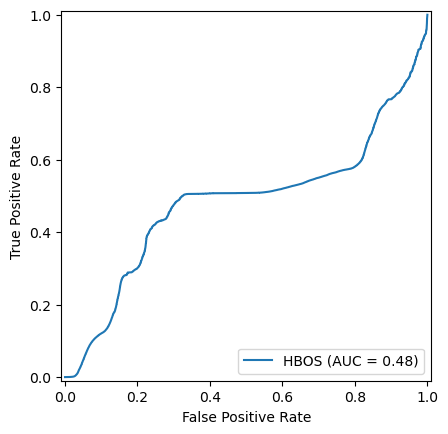

In [30]:
show_roc(hbos, "HBOS")

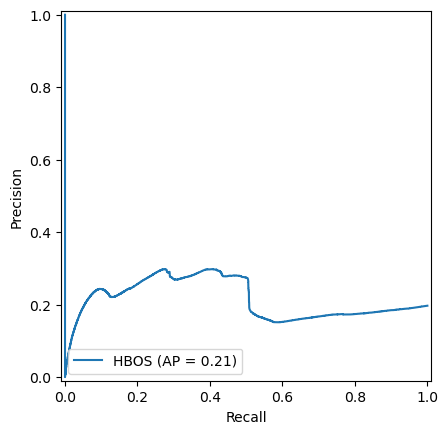

In [31]:
show_prc(hbos, "HBOS")

In [32]:
evaluate_metrics(sampling, "Sampling")

Sampling test accuracy: 0.653
Sampling test recall: 0.166
Sampling test precision: 0.152


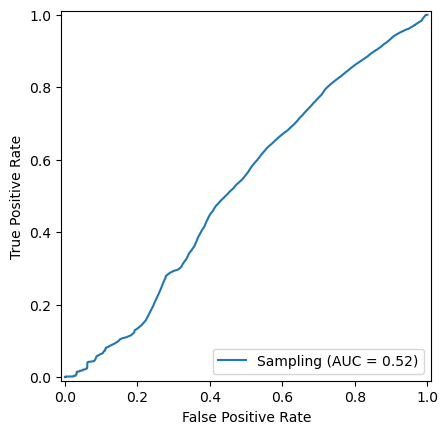

In [33]:
show_roc(sampling, "Sampling")

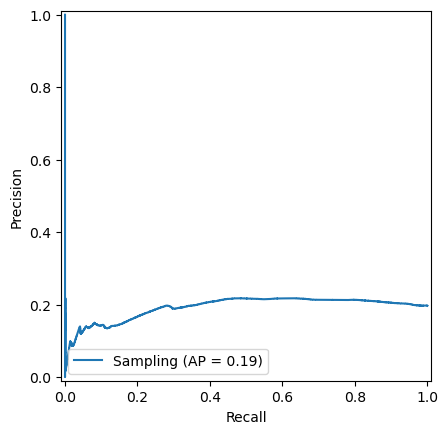

In [34]:
show_prc(sampling, "Sampling")

In [35]:
evaluate_metrics(naive_bayes, "GaussianNB")

GaussianNB test accuracy: 0.601
GaussianNB test recall: 0.996
GaussianNB test precision: 0.330


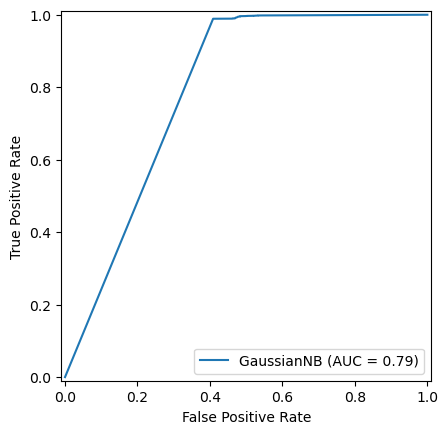

In [36]:
show_roc(naive_bayes, "GaussianNB")

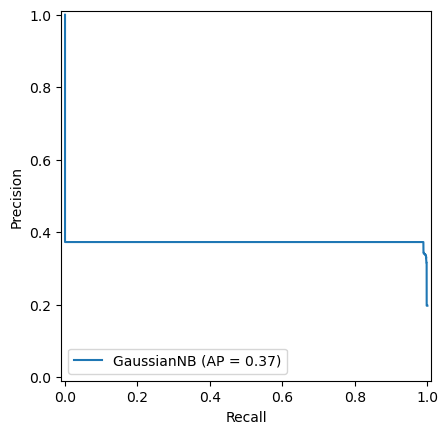

In [37]:
show_prc(naive_bayes, "GaussianNB")

In [38]:
evaluate_metrics(qda, "QuadraticDiscriminantAnalysis")

QuadraticDiscriminantAnalysis test accuracy: 0.816
QuadraticDiscriminantAnalysis test recall: 0.380
QuadraticDiscriminantAnalysis test precision: 0.547


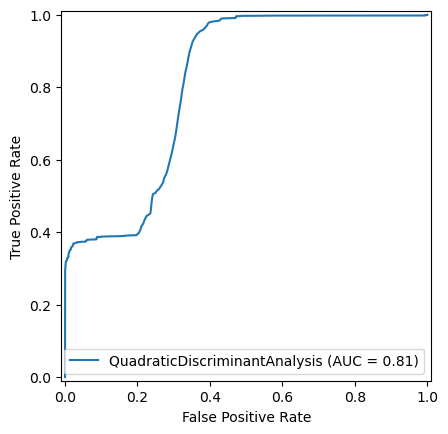

In [39]:
show_roc(qda, "QuadraticDiscriminantAnalysis")

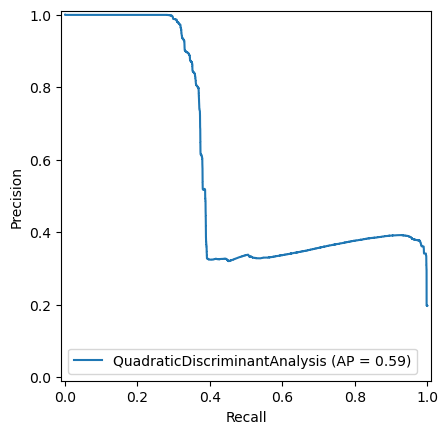

In [40]:
show_prc(qda, "QuadraticDiscriminantAnalysis")

In [41]:
evaluate_metrics(logistic_regression, "LogisticRegression")

LogisticRegression test accuracy: 0.893
LogisticRegression test recall: 0.817
LogisticRegression test precision: 0.695


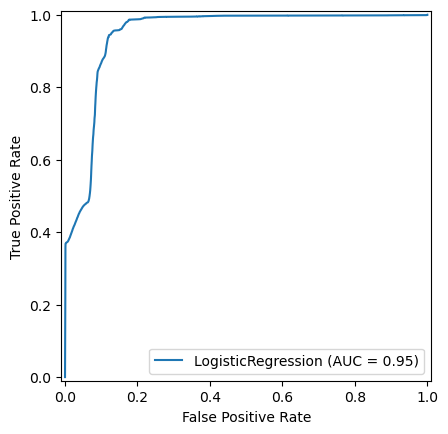

In [42]:
show_roc(logistic_regression, "LogisticRegression")

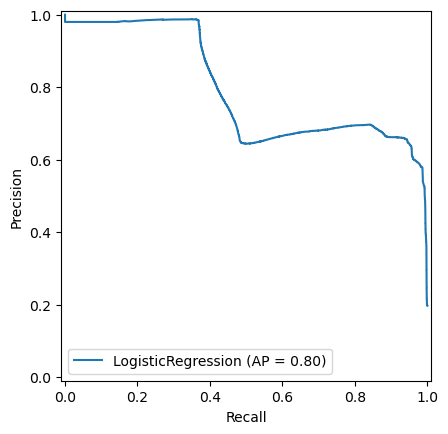

In [43]:
show_prc(logistic_regression, "LogisticRegression")

In [44]:
evaluate_metrics(xgb, "XGBClassifier")

XGBClassifier test accuracy: 0.989
XGBClassifier test recall: 0.994
XGBClassifier test precision: 0.954


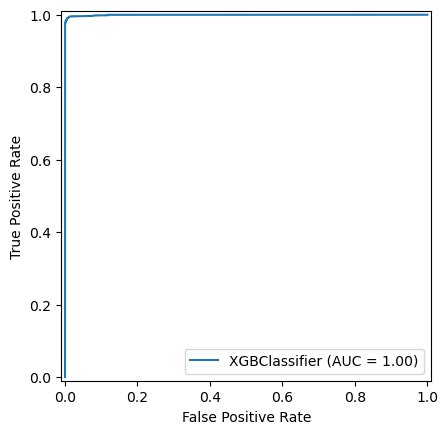

In [45]:
show_roc(xgb, "XGBClassifier")

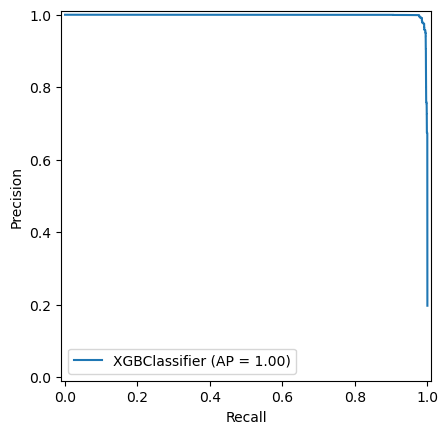

In [46]:
show_prc(xgb, "XGBClassifier")

## 1.2.11 - Computing anomaly score 

In [47]:
# choose the anomaly detector you want to use
anomaly_score=logistic_regression.predict_proba(X_test)[:,1]

## 1.3 - Computing attack type score

### 1.3.1 - Loading the datasets

In [48]:
import numpy as np
import pandas as pd
df_train=pd.read_csv("./CSVs/merged/Train.csv")
df_test=pd.read_csv("./CSVs/merged/Test.csv")

### 1.3.2 - Categorical encoding for type mapping

In [49]:
df_dict_train={}
df_dict_test={}
attack_types=[label for label, value in df_train['Label'].value_counts().items() if label!='BENIGN' and value > 667]
print(attack_types)
for label in attack_types:
    df_dict_train[label]=label_encode(df_train, [label])
    df_dict_test[label]=label_encode(df_test, [label])

['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack \x96 Brute Force']


In [50]:
for label in attack_types:
    print(label)
    print("train set")
    print(df_dict_train[label]["Label"].value_counts())
    print("test set")
    print(df_dict_test[label]["Label"].value_counts())

DoS Hulk
train set
Label
0    1741773
1     154818
Name: count, dtype: int64
test set
Label
0    857897
1     76255
Name: count, dtype: int64
PortScan
train set
Label
0    1790108
1     106483
Name: count, dtype: int64
test set
Label
0    881705
1     52447
Name: count, dtype: int64
DDoS
train set
Label
0    1810813
1      85778
Name: count, dtype: int64
test set
Label
0    891903
1     42249
Name: count, dtype: int64
DoS GoldenEye
train set
Label
0    1889695
1       6896
Name: count, dtype: int64
test set
Label
0    930755
1      3397
Name: count, dtype: int64
FTP-Patator
train set
Label
0    1891273
1       5318
Name: count, dtype: int64
test set
Label
0    931532
1      2620
Name: count, dtype: int64
SSH-Patator
train set
Label
0    1892641
1       3950
Name: count, dtype: int64
test set
Label
0    932205
1      1947
Name: count, dtype: int64
DoS slowloris
train set
Label
0    1892708
1       3883
Name: count, dtype: int64
test set
Label
0    932239
1      1913
Name: count, dtype: 

### 1.3.3 - Feature removal

In [51]:
rm_cols=["Flow ID", "Source IP", "Destination IP", "Timestamp"]
for label in attack_types:
    df_dict_train[label] = df_dict_train[label].drop(rm_cols, axis=1)
    df_dict_test[label] = df_dict_test[label].drop(rm_cols, axis=1)
    df_dict_train[label].info()
    df_dict_test[label].info()

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 81 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  Flow IAT St

### 1.3.4 - Feature label separation

In [52]:
y_train_dict={}
X_train_dict={}
y_test_dict={}
X_test_dict={}

for label in attack_types:
    y_train_dict[label], X_train_dict[label]= df_dict_train[label]["Label"], df_dict_train[label].drop("Label", axis=1)
    y_test_dict[label], X_test_dict[label]= df_dict_test[label]["Label"], df_dict_test[label].drop("Label", axis=1)
    X_train_dict[label].info()
    X_test_dict[label].info()

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  Flow IAT St

### 1.3.5 - Standardization

In [53]:
from sklearn.preprocessing import StandardScaler
for label in attack_types:
    scaler = StandardScaler()
    scaler.fit(X_train_dict[label])
    X_train_dict[label] = scaler.transform(X_train_dict[label])
    X_test_dict[label] = scaler.transform(X_test_dict[label])

### 1.3.5 - Train type mappers

In [54]:
from xgboost import XGBClassifier
xgb_dict={}
for label in attack_types:
    xgboost=XGBClassifier(n_estimators=50, random_state=42)
    xgboost.fit(X_train_dict[label], y_train_dict[label])
    xgb_dict[label]=xgboost

In [55]:
from sklearn.naive_bayes import GaussianNB
naive_bayes_dict={}
for label in attack_types:
    nb=GaussianNB()
    nb.fit(X_train_dict[label], y_train_dict[label])
    naive_bayes_dict[label]=nb

In [56]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda_dict={}
for label in attack_types:
    qda = QuadraticDiscriminantAnalysis(reg_param=1.0)
    qda.fit(X_train_dict[label], y_train_dict[label])
    qda_dict[label]=qda

In [57]:
from sklearn.linear_model import LogisticRegression
logistic_regression_dict={}
for label in attack_types:
    logistic_regression=LogisticRegression(max_iter=500, random_state=42)
    logistic_regression.fit(X_train_dict[label], y_train_dict[label])
    logistic_regression_dict[label]=logistic_regression

### 1.3.6 - Test type mapper function definition

In [58]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
def evaluate_mapper(mapper_dict, name):
    for label, xgboost in mapper_dict.items(): 
        y_pred=xgboost.predict(X_test_dict[label])
        acc=accuracy_score(y_test_dict[label], y_pred)
        print(f"{name} test accuracy for {label}: {acc:.3f}")
        rec=recall_score(y_test_dict[label], y_pred)
        print(f"{name} test recall for {label}: {rec:.3f}")
        rec=precision_score(y_test_dict[label], y_pred)
        print(f"{name} test precision for {label}: {rec:.3f}")

### 1.3.7 - Mapper ROC curve function definition

In [59]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

def show_roc_mapper(mapper_dict, name):
    prob_dict={}
    for label, predictor in mapper_dict.items():
        y_prob = predictor.predict_proba(X_test_dict[label])[:, 1]
        prob_dict[label]=y_prob
        
        fpr, tpr, _ = roc_curve(y_test_dict[label], y_prob)
        roc_auc = roc_auc_score(y_test_dict[label], y_prob)
        
        fig1, ax1 = plt.subplots()
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f"{name} "+label).plot(ax=ax1)
        ax1.set_title(f"ROC — {label}")
    
    plt.show() 

### 1.3.8 - Mapper Precision-Recall curve function definition

In [60]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

def show_prc_mapper(mapper_dict, name):
    prob_dict={}
    for label, predictor in mapper_dict.items():
        y_prob = predictor.predict_proba(X_test_dict[label])[:, 1]
        prob_dict[label]=y_prob
        
        pre, rec, _ = precision_recall_curve(y_test_dict[label], y_prob)
        avg_pre = average_precision_score(y_test_dict[label], y_prob)
        
        fig2, ax2 = plt.subplots()
        PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name=f"{name} "+label).plot(ax=ax2)
        ax2.set_title(f"Precision-Recall — {label}")
    
    plt.show() 

### 1.3.9 - Test atatck type mappers

In [61]:
evaluate_mapper(xgb_dict,"XGBoostClassifier")

XGBoostClassifier test accuracy for DoS Hulk: 0.998
XGBoostClassifier test recall for DoS Hulk: 0.972
XGBoostClassifier test precision for DoS Hulk: 0.999
XGBoostClassifier test accuracy for PortScan: 1.000
XGBoostClassifier test recall for PortScan: 0.998
XGBoostClassifier test precision for PortScan: 1.000
XGBoostClassifier test accuracy for DDoS: 0.989
XGBoostClassifier test recall for DDoS: 0.999
XGBoostClassifier test precision for DDoS: 0.803
XGBoostClassifier test accuracy for DoS GoldenEye: 1.000
XGBoostClassifier test recall for DoS GoldenEye: 0.943
XGBoostClassifier test precision for DoS GoldenEye: 0.970
XGBoostClassifier test accuracy for FTP-Patator: 1.000
XGBoostClassifier test recall for FTP-Patator: 0.997
XGBoostClassifier test precision for FTP-Patator: 0.995
XGBoostClassifier test accuracy for SSH-Patator: 1.000
XGBoostClassifier test recall for SSH-Patator: 0.953
XGBoostClassifier test precision for SSH-Patator: 1.000
XGBoostClassifier test accuracy for DoS slowloris

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

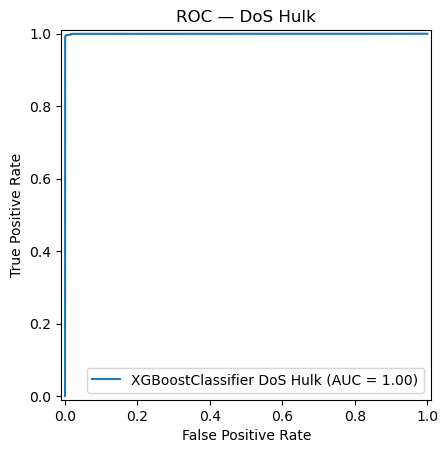

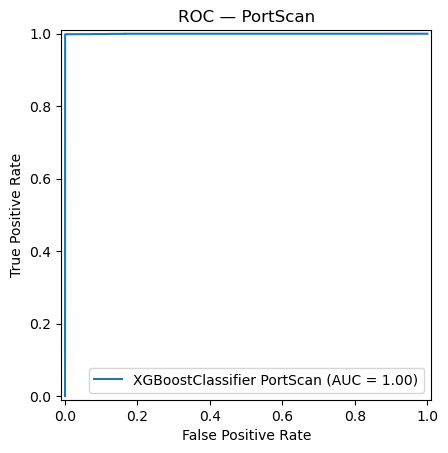

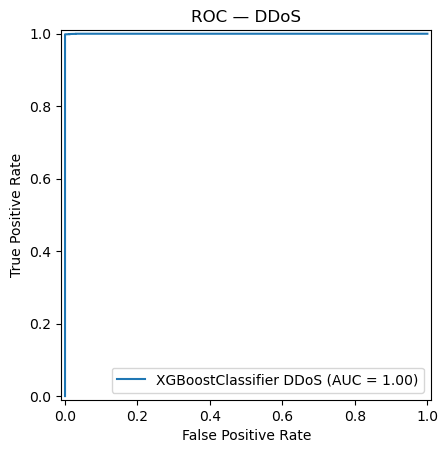

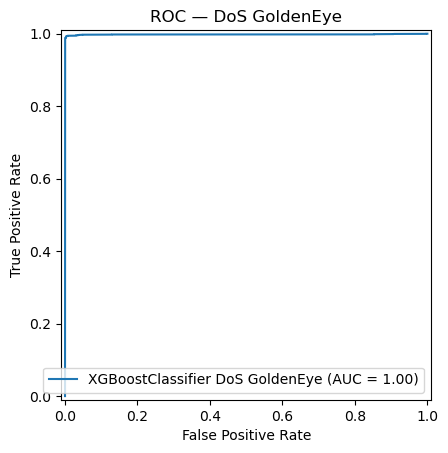

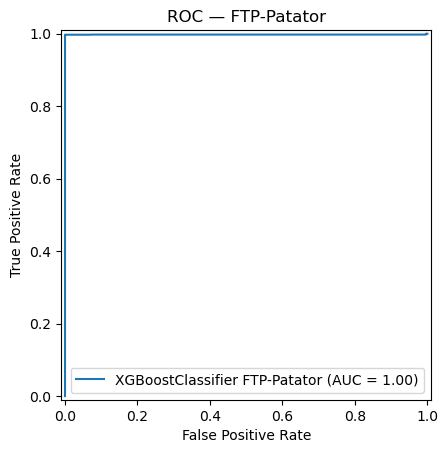

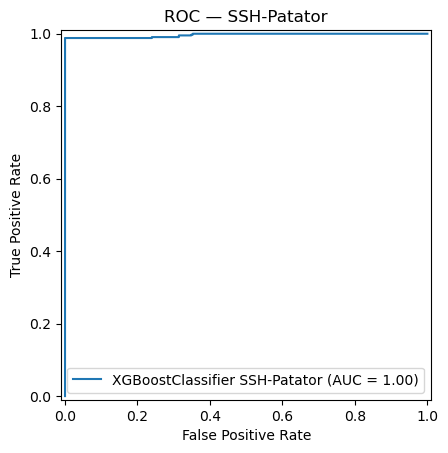

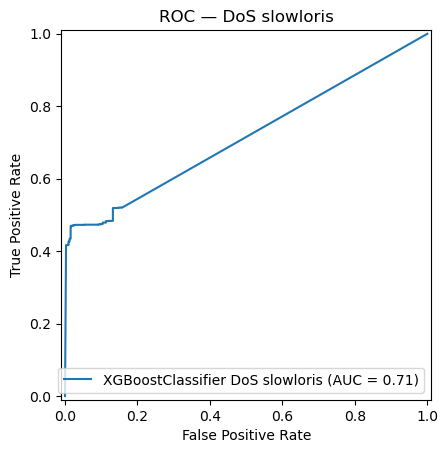

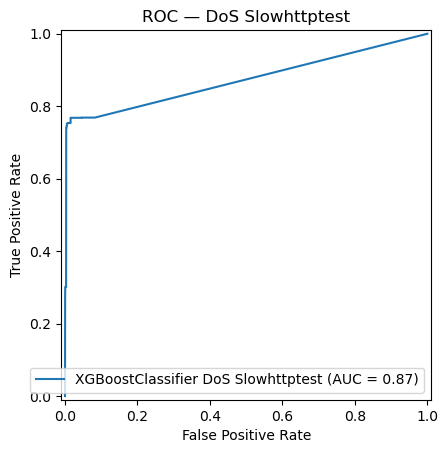

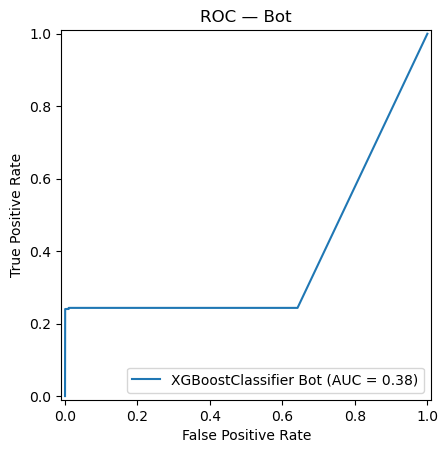

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


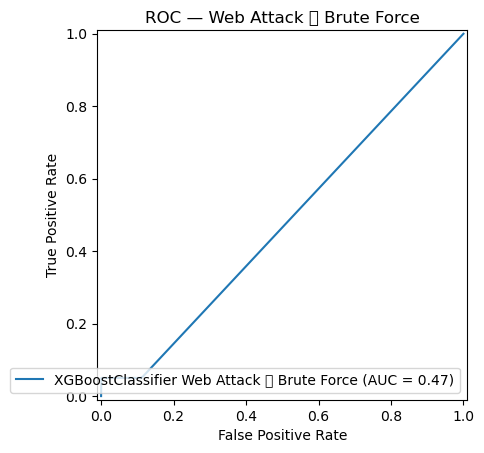

In [62]:
show_roc_mapper(xgb_dict,"XGBoostClassifier")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

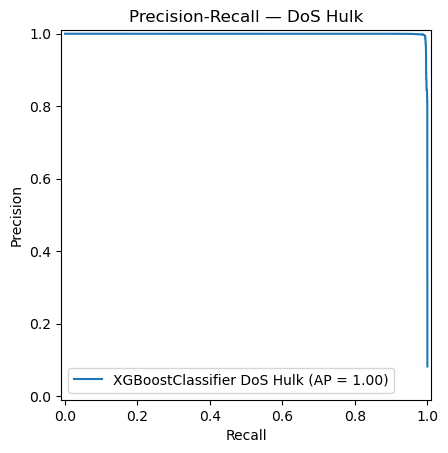

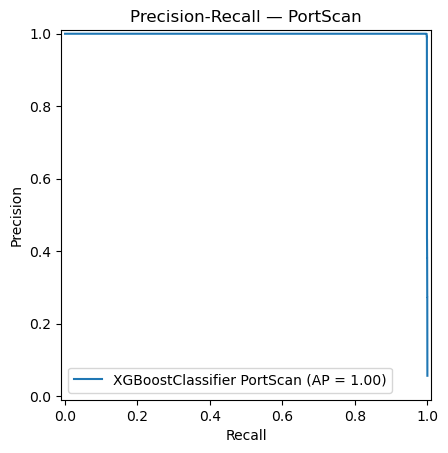

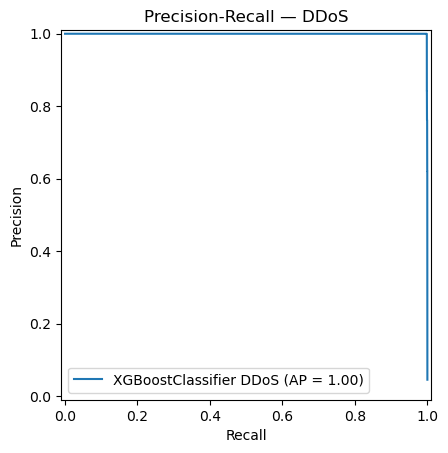

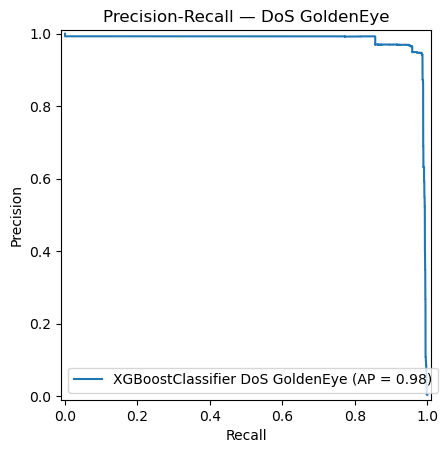

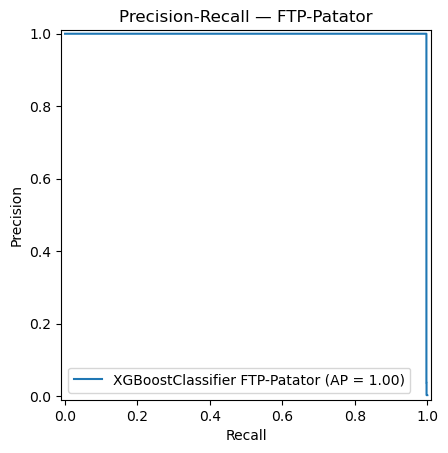

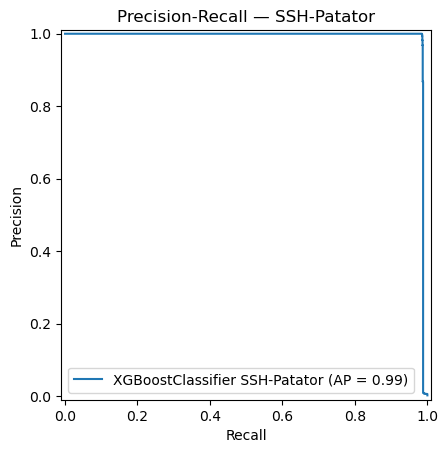

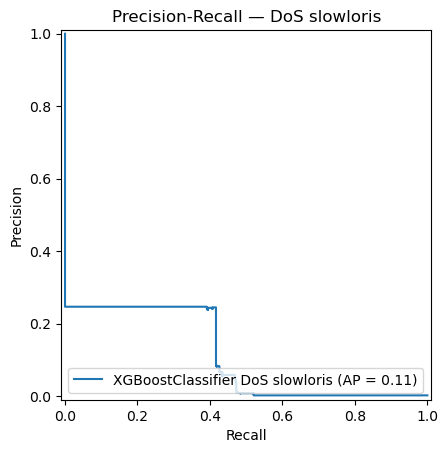

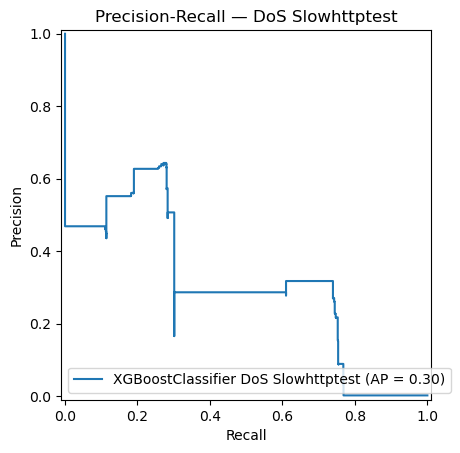

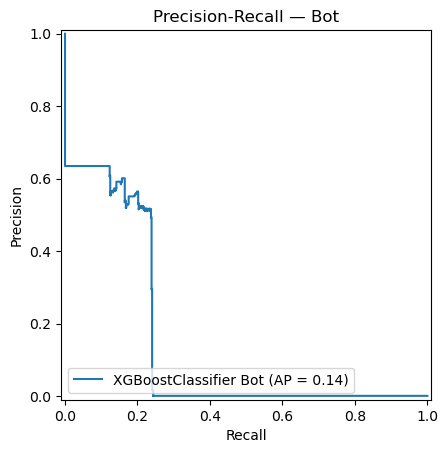

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


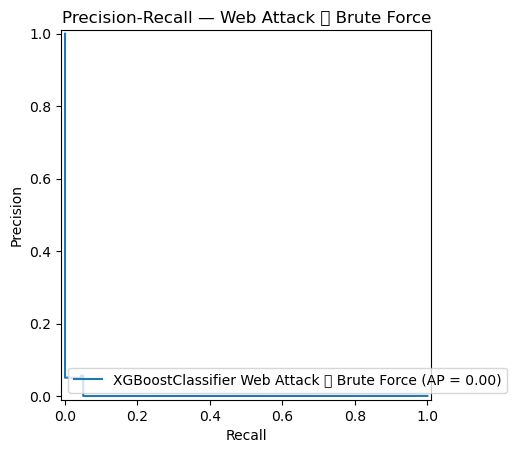

In [63]:
show_prc_mapper(xgb_dict,"XGBoostClassifier")

In [64]:
evaluate_mapper(naive_bayes_dict,"GaussianNB")

GaussianNB test accuracy for DoS Hulk: 0.956
GaussianNB test recall for DoS Hulk: 0.991
GaussianNB test precision for DoS Hulk: 0.652
GaussianNB test accuracy for PortScan: 0.966
GaussianNB test recall for PortScan: 0.993
GaussianNB test precision for PortScan: 0.625
GaussianNB test accuracy for DDoS: 0.882
GaussianNB test recall for DDoS: 0.998
GaussianNB test precision for DDoS: 0.277
GaussianNB test accuracy for DoS GoldenEye: 0.929
GaussianNB test recall for DoS GoldenEye: 0.998
GaussianNB test precision for DoS GoldenEye: 0.049
GaussianNB test accuracy for FTP-Patator: 0.999
GaussianNB test recall for FTP-Patator: 0.997
GaussianNB test precision for FTP-Patator: 0.777
GaussianNB test accuracy for SSH-Patator: 0.995
GaussianNB test recall for SSH-Patator: 0.987
GaussianNB test precision for SSH-Patator: 0.297
GaussianNB test accuracy for DoS slowloris: 0.968
GaussianNB test recall for DoS slowloris: 0.884
GaussianNB test precision for DoS slowloris: 0.054
GaussianNB test accuracy f

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

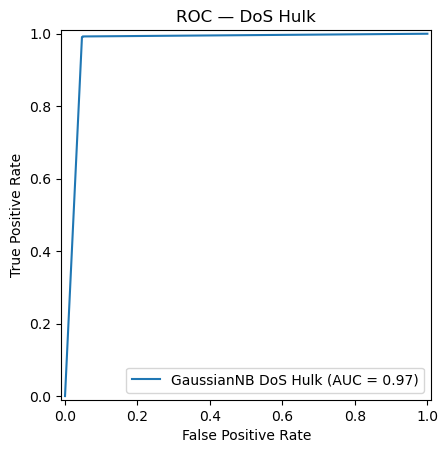

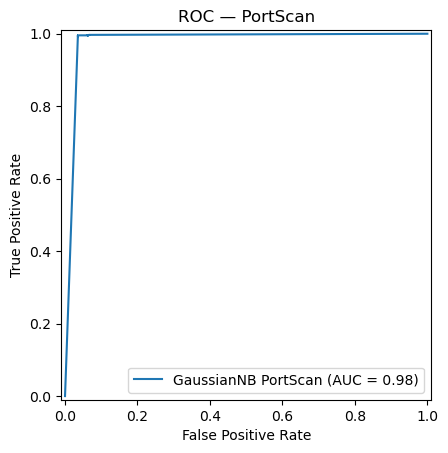

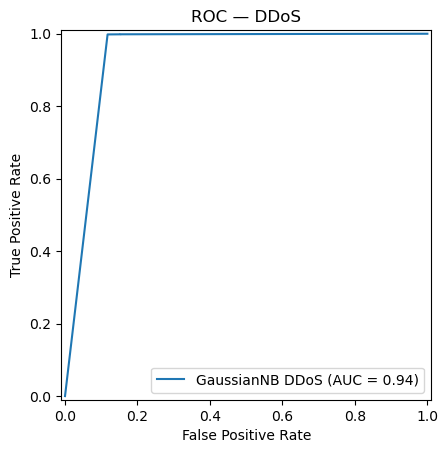

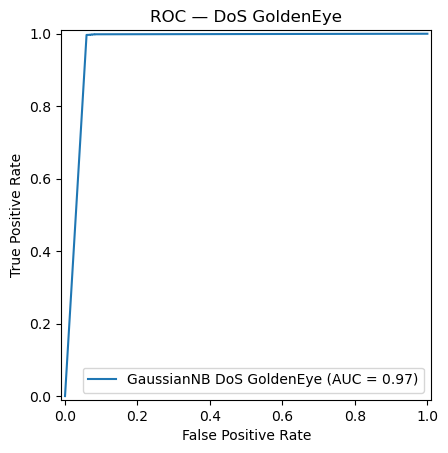

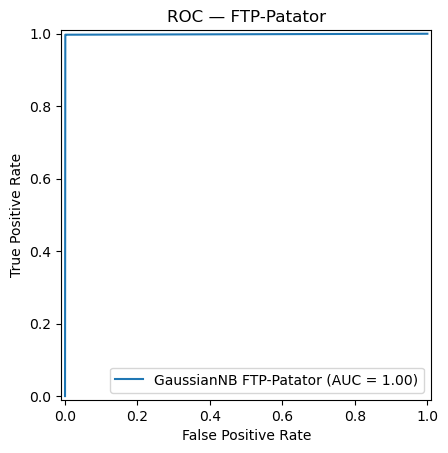

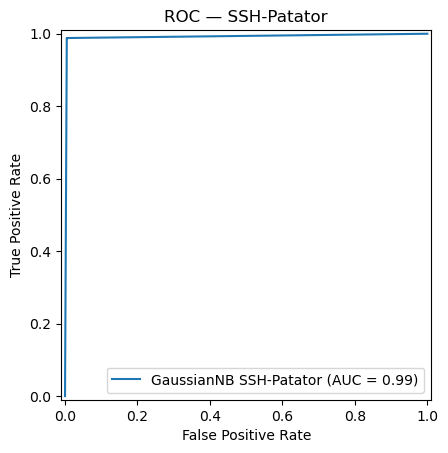

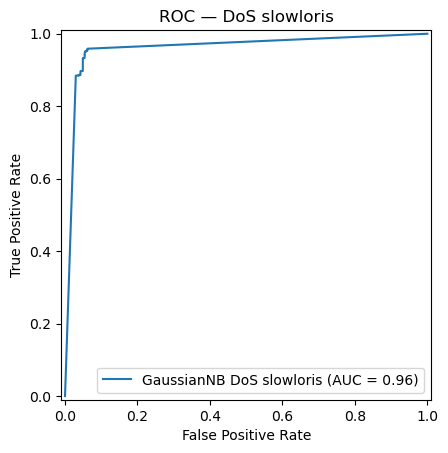

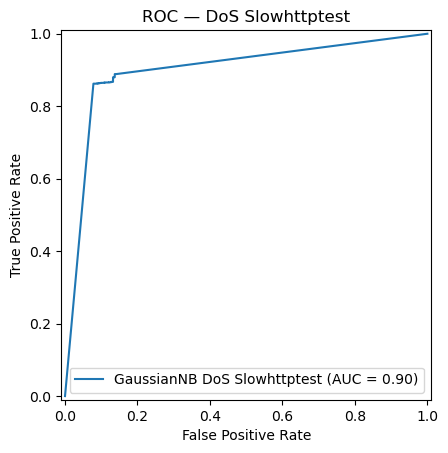

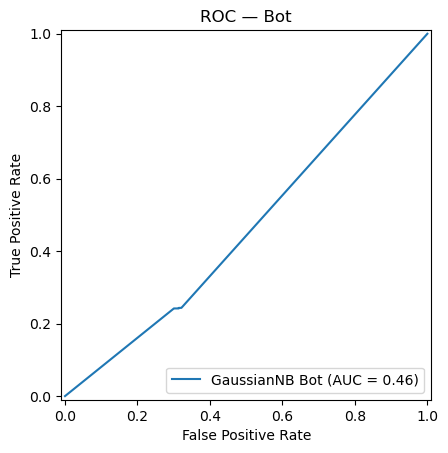

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


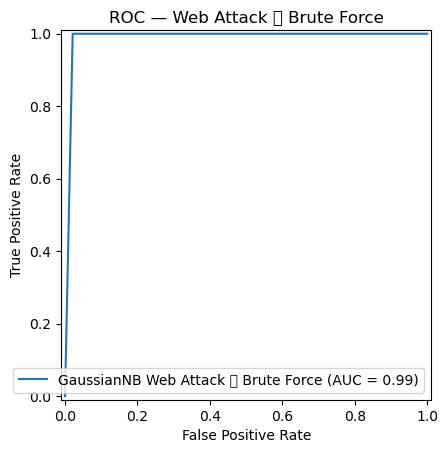

In [65]:
show_roc_mapper(naive_bayes_dict,"GaussianNB")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

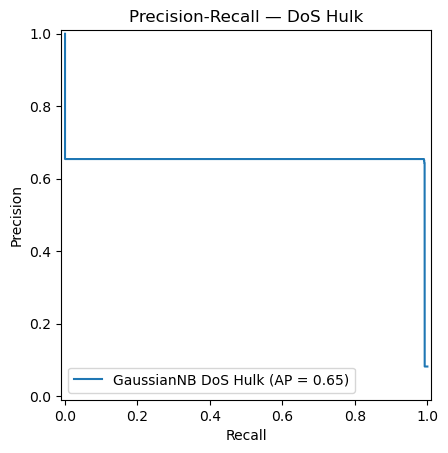

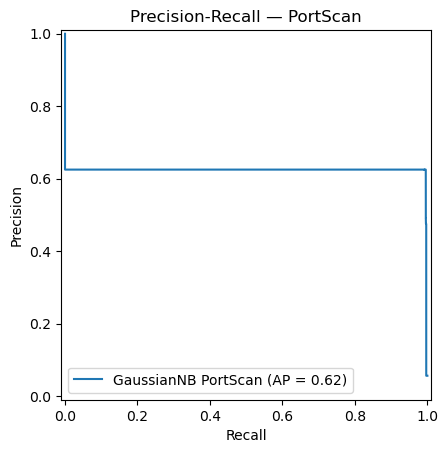

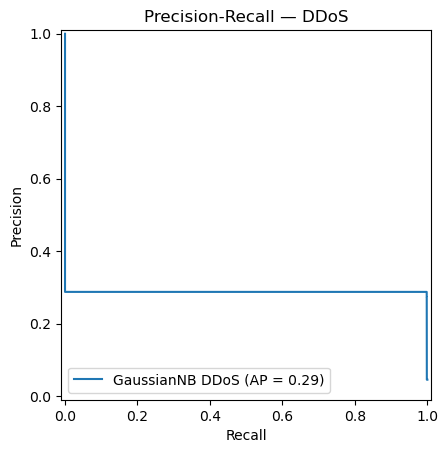

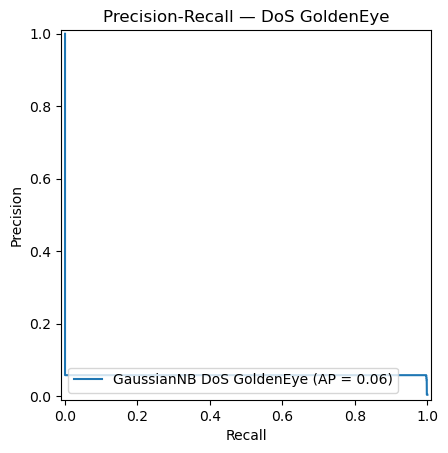

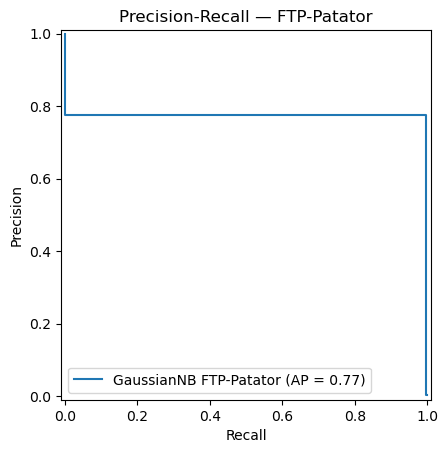

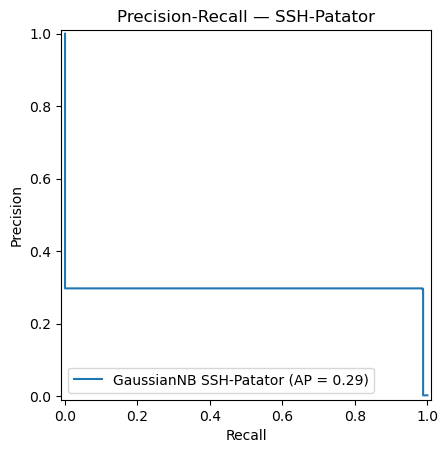

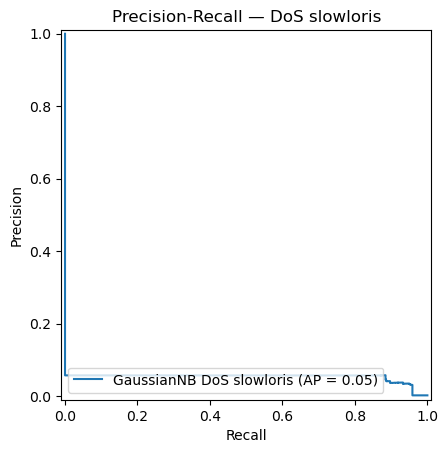

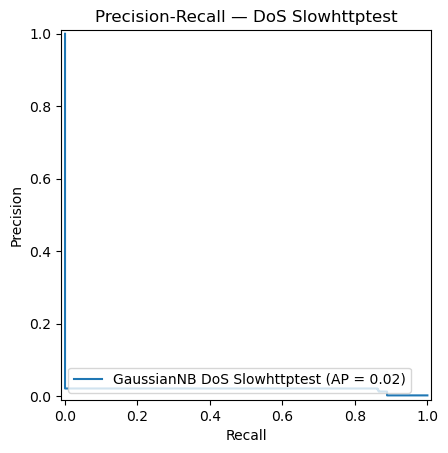

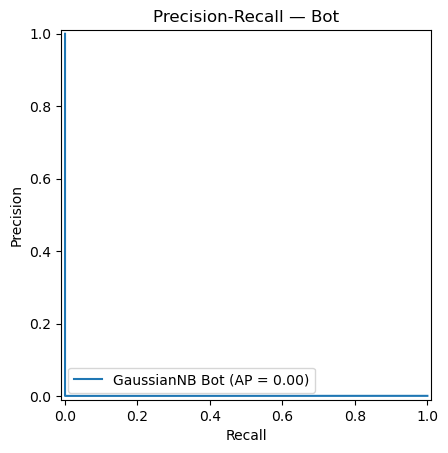

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


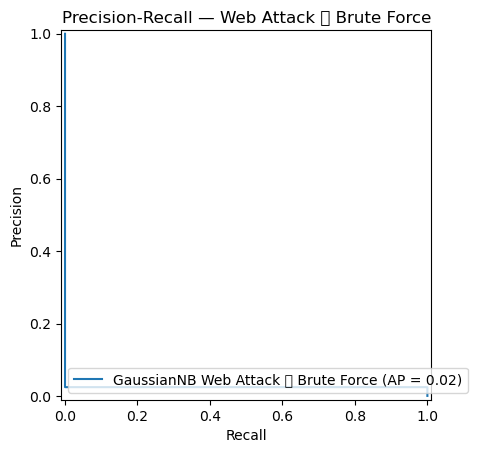

In [66]:
show_prc_mapper(naive_bayes_dict,"GaussianNB")

In [67]:
evaluate_mapper(qda_dict,"QuadraticDiscriminantAnalysis")

QuadraticDiscriminantAnalysis test accuracy for DoS Hulk: 0.904
QuadraticDiscriminantAnalysis test recall for DoS Hulk: 0.542
QuadraticDiscriminantAnalysis test precision for DoS Hulk: 0.432
QuadraticDiscriminantAnalysis test accuracy for PortScan: 0.921
QuadraticDiscriminantAnalysis test recall for PortScan: 0.996
QuadraticDiscriminantAnalysis test precision for PortScan: 0.416
QuadraticDiscriminantAnalysis test accuracy for DDoS: 0.924
QuadraticDiscriminantAnalysis test recall for DDoS: 0.586
QuadraticDiscriminantAnalysis test precision for DDoS: 0.315
QuadraticDiscriminantAnalysis test accuracy for DoS GoldenEye: 0.929
QuadraticDiscriminantAnalysis test recall for DoS GoldenEye: 0.470
QuadraticDiscriminantAnalysis test precision for DoS GoldenEye: 0.024
QuadraticDiscriminantAnalysis test accuracy for FTP-Patator: 0.968
QuadraticDiscriminantAnalysis test recall for FTP-Patator: 0.498
QuadraticDiscriminantAnalysis test precision for FTP-Patator: 0.043
QuadraticDiscriminantAnalysis tes

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

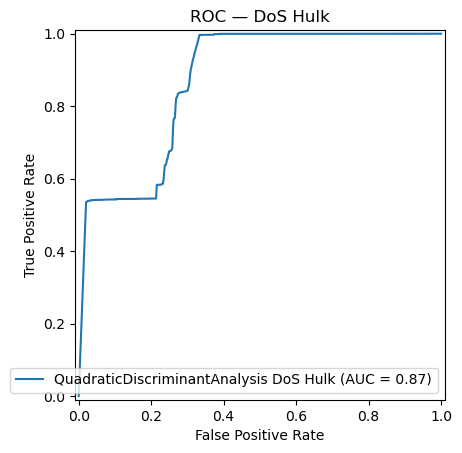

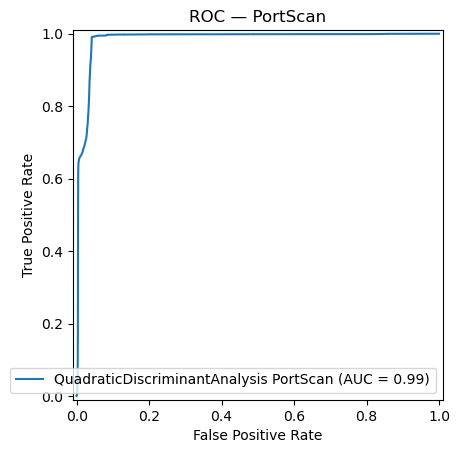

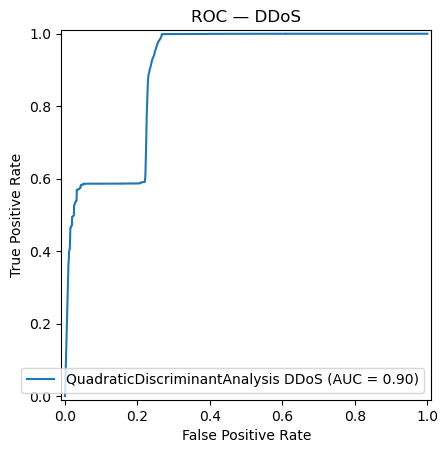

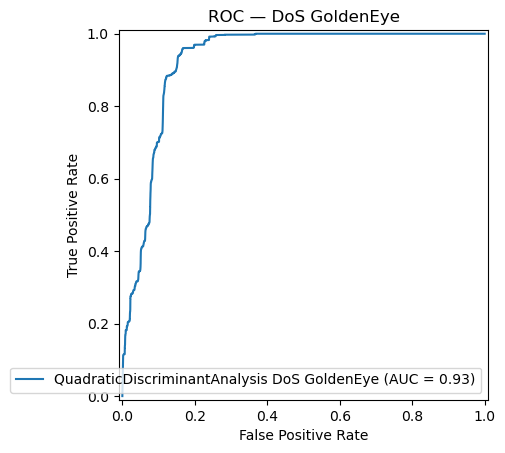

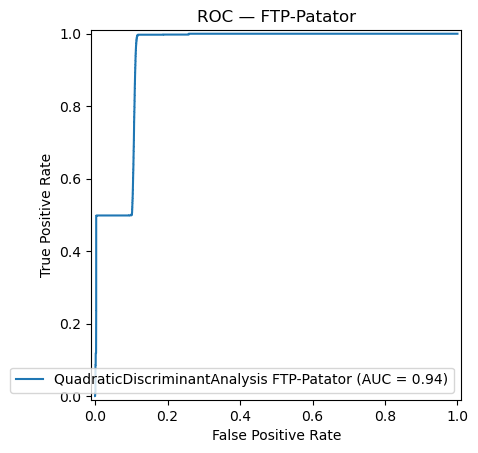

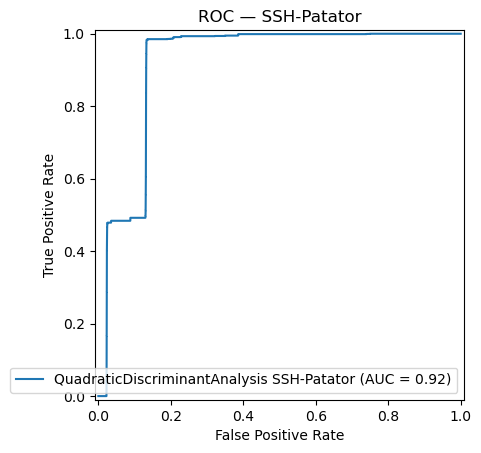

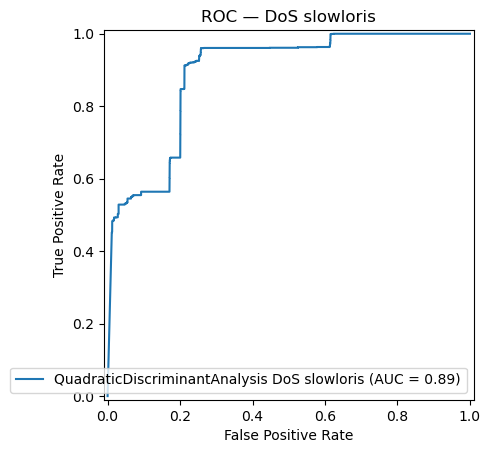

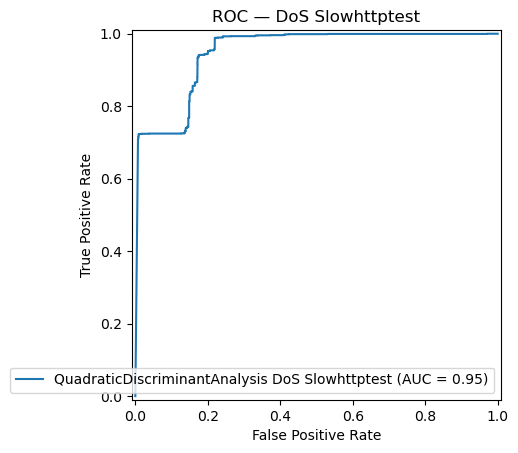

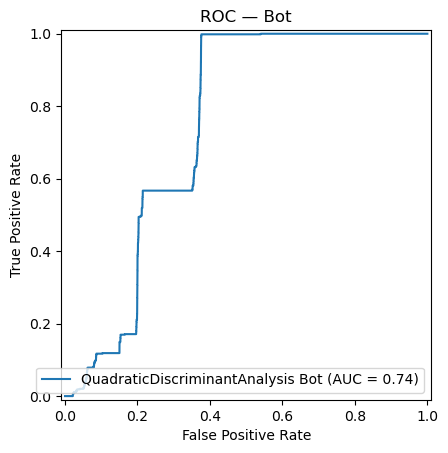

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


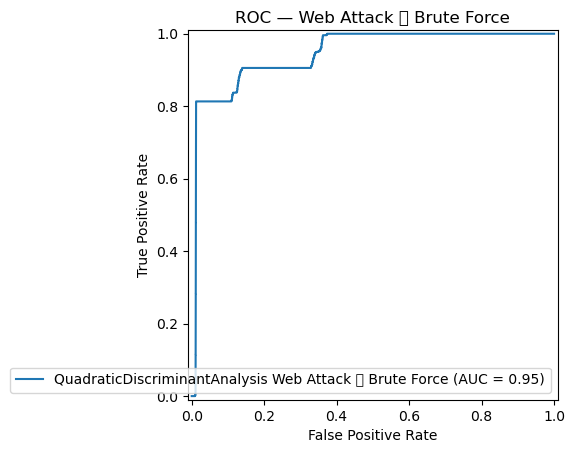

In [68]:
show_roc_mapper(qda_dict,"QuadraticDiscriminantAnalysis")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

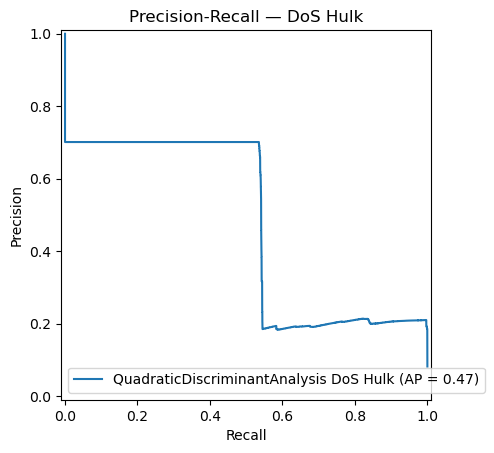

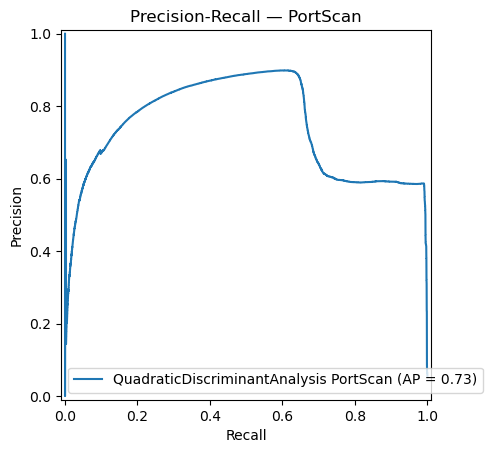

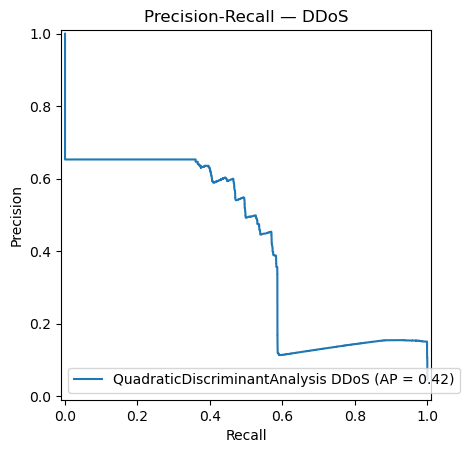

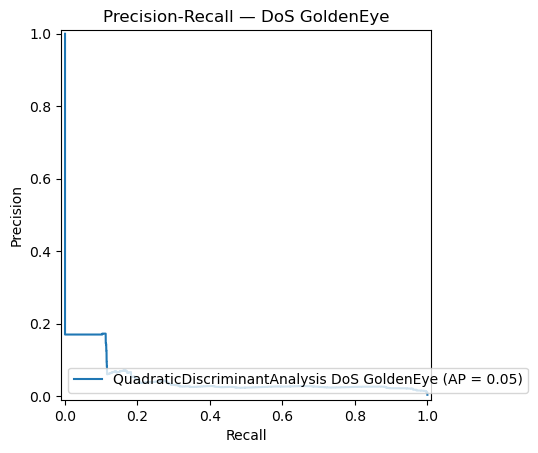

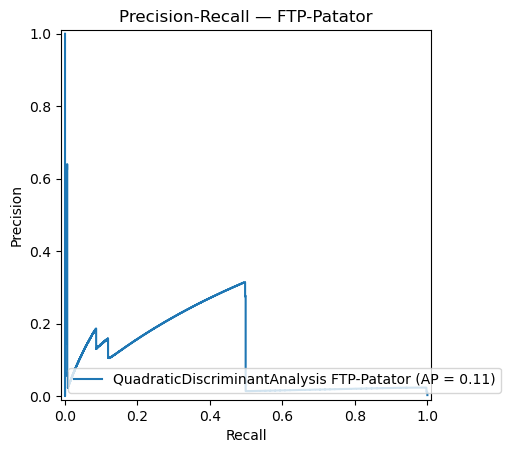

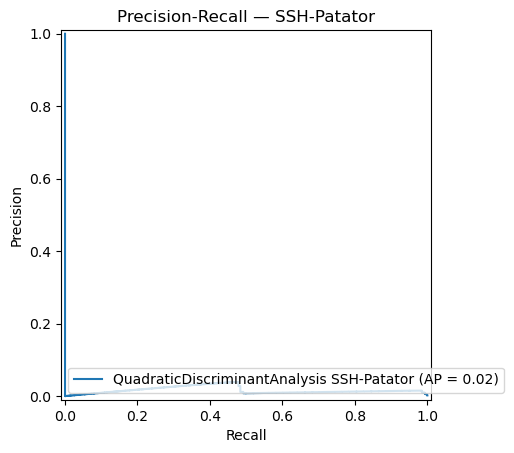

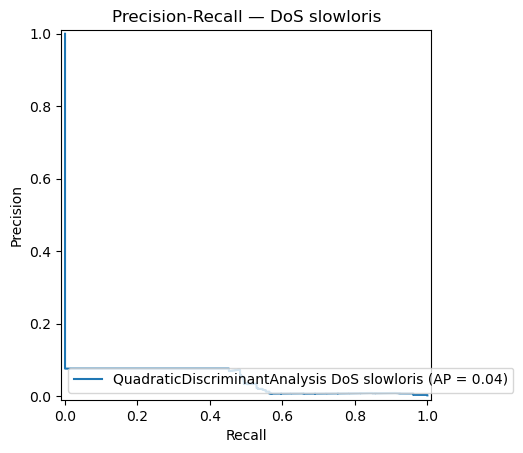

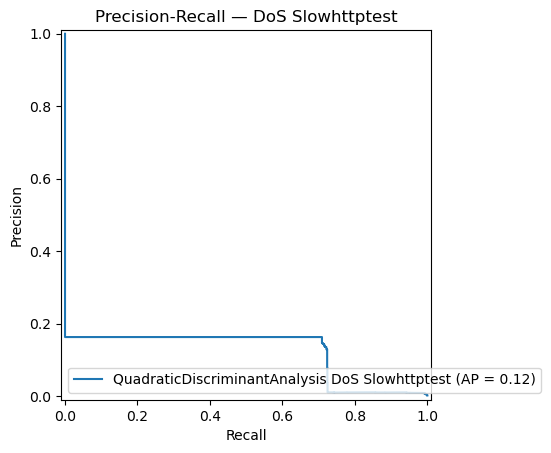

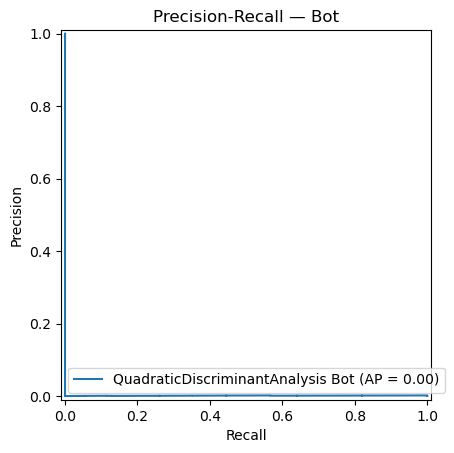

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


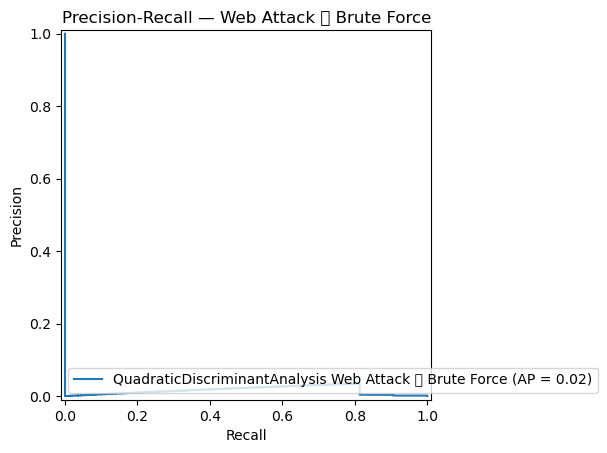

In [69]:
show_prc_mapper(qda_dict,"QuadraticDiscriminantAnalysis")

In [70]:
evaluate_mapper(logistic_regression_dict,"LogisticRegression")

LogisticRegression test accuracy for DoS Hulk: 0.980
LogisticRegression test recall for DoS Hulk: 0.760
LogisticRegression test precision for DoS Hulk: 0.990
LogisticRegression test accuracy for PortScan: 0.963
LogisticRegression test recall for PortScan: 0.992
LogisticRegression test precision for PortScan: 0.602
LogisticRegression test accuracy for DDoS: 0.998
LogisticRegression test recall for DDoS: 0.951
LogisticRegression test precision for DDoS: 0.996
LogisticRegression test accuracy for DoS GoldenEye: 0.999
LogisticRegression test recall for DoS GoldenEye: 0.719
LogisticRegression test precision for DoS GoldenEye: 0.917
LogisticRegression test accuracy for FTP-Patator: 1.000
LogisticRegression test recall for FTP-Patator: 0.995
LogisticRegression test precision for FTP-Patator: 0.947
LogisticRegression test accuracy for SSH-Patator: 0.999
LogisticRegression test recall for SSH-Patator: 0.485
LogisticRegression test precision for SSH-Patator: 0.901
LogisticRegression test accurac

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

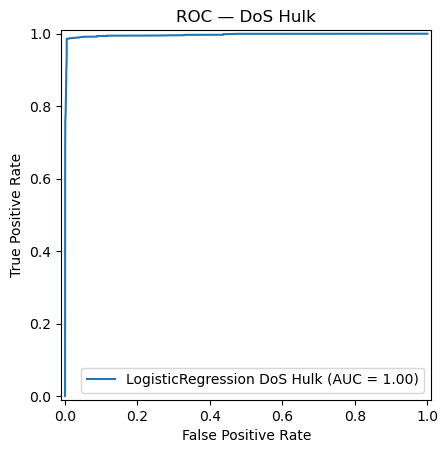

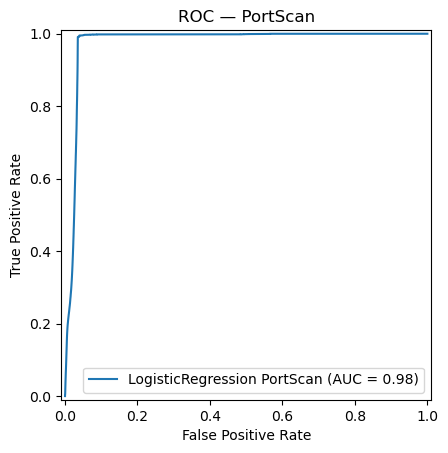

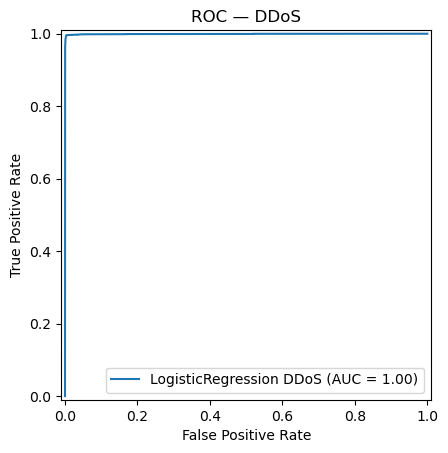

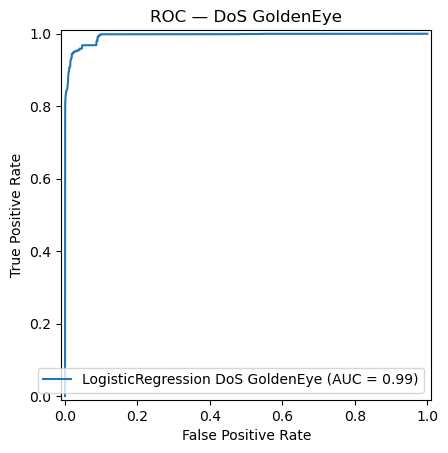

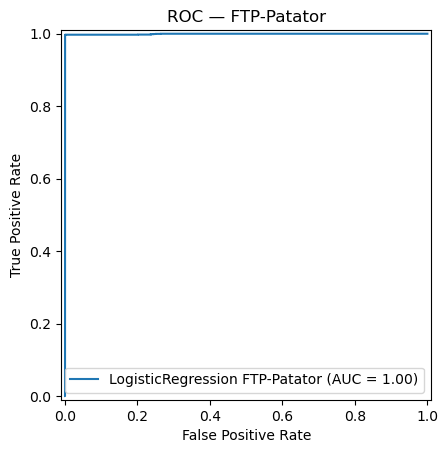

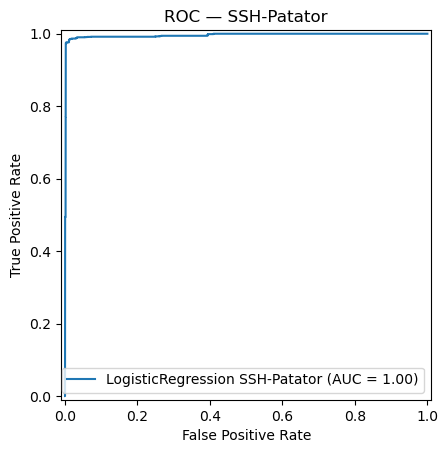

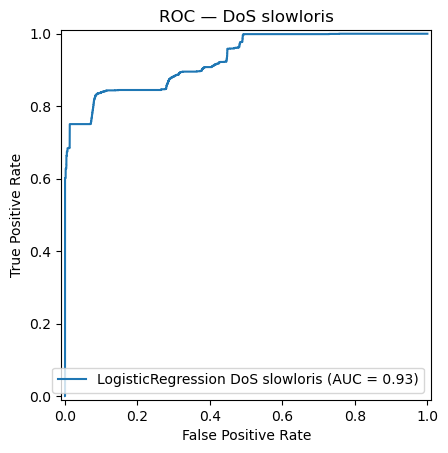

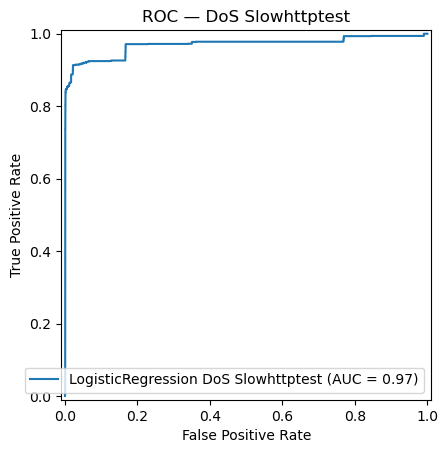

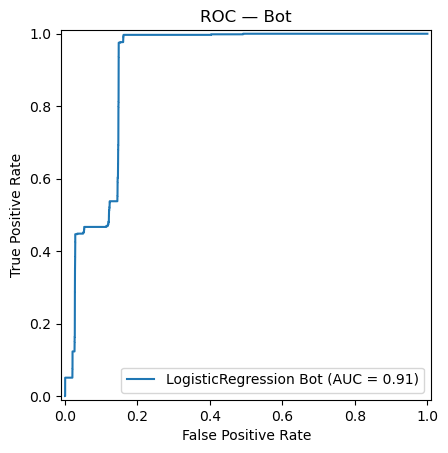

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


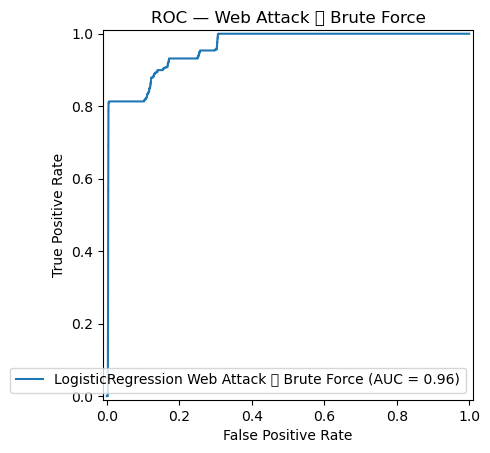

In [71]:
show_roc_mapper(logistic_regression_dict,"LogisticRegression")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

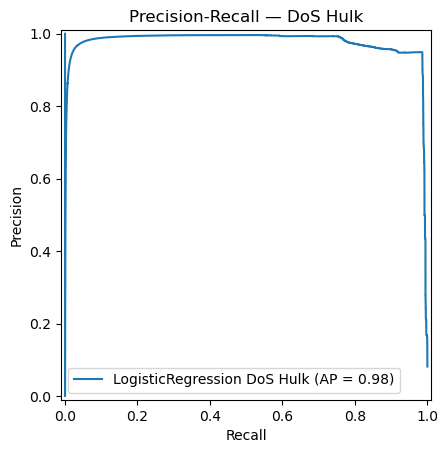

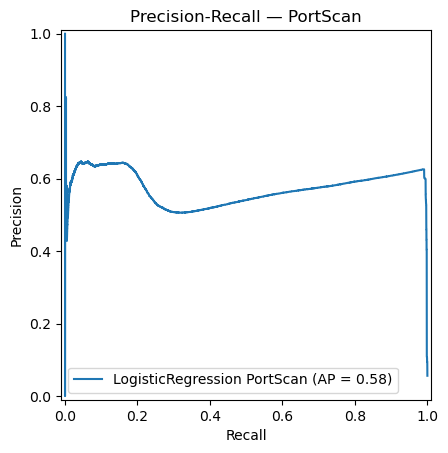

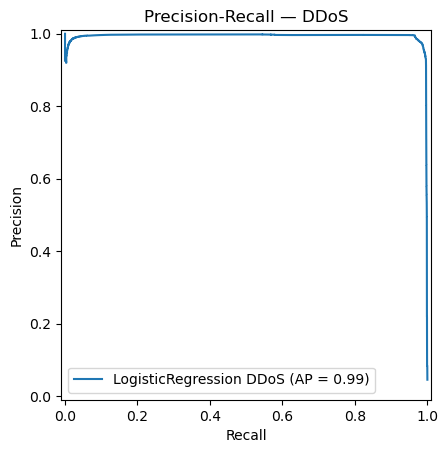

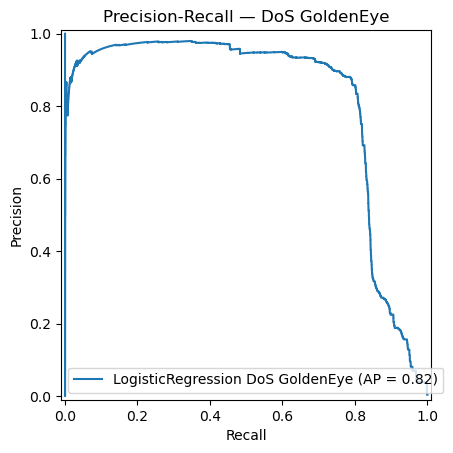

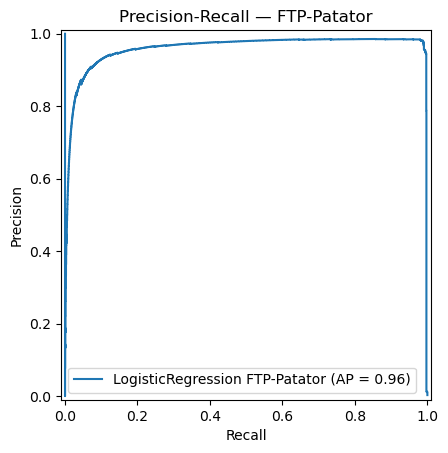

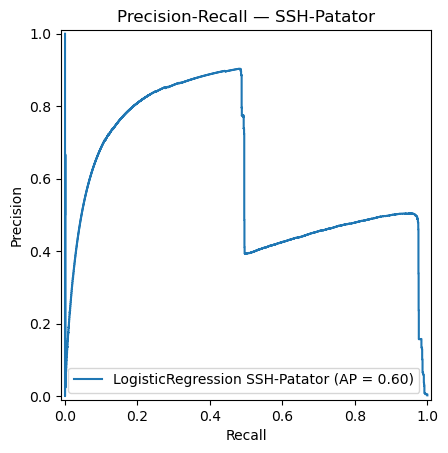

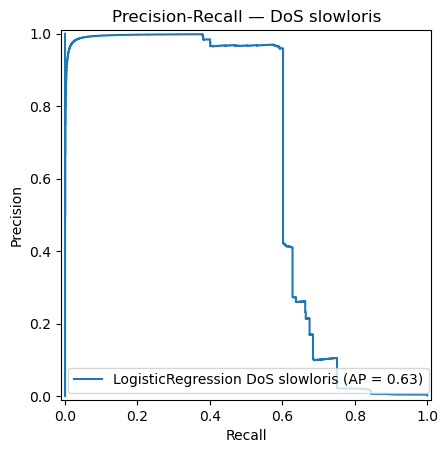

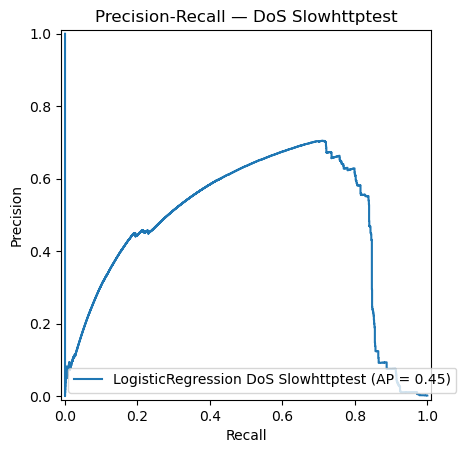

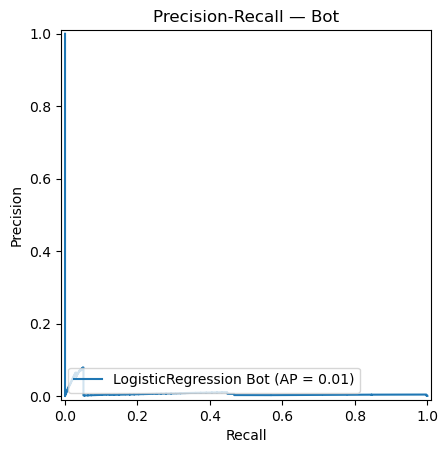

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


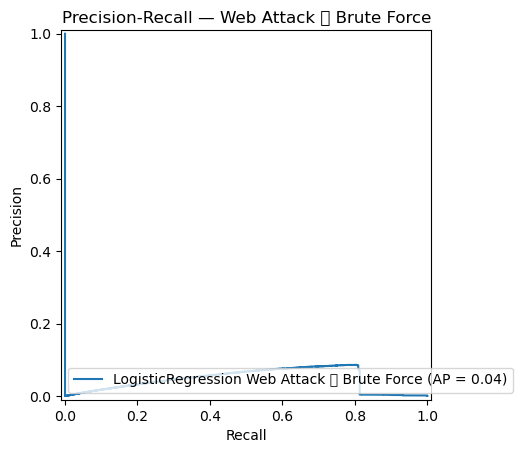

In [72]:
show_prc_mapper(logistic_regression_dict,"LogisticRegression")

### 1.3.10 - Computing attack type score

In [73]:
# choose the attack type mapper you want to use
attack_type_prob={}
for label, xgboost in xgb_dict.items():
    y_prob = xgboost.predict_proba(X_test_dict[label])[:, 1]
    attack_type_prob[label]=y_prob

## 1.4 - Building the scenario reconstruction dataset

### 1.4.1 - Loading the starting dataset 

In [74]:
import numpy as np
import pandas as pd
df_rec=pd.read_csv("./CSVs/merged/Test.csv")

### 1.4.2 - Extracting reconstruction features

In [75]:
rec_cols=["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Protocol", "Timestamp", "Flow Duration"]
df_rec=df_rec[["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port",  "Protocol", "Timestamp", "Flow Duration"]]

### 1.4.3 - Adding new features

In [76]:
df_rec["Anomaly Score"]=anomaly_score
for attack_type, type_prob in attack_type_prob.items():
    df_rec[attack_type]=type_prob
df_rec.info()

<class 'pandas.DataFrame'>
RangeIndex: 934152 entries, 0 to 934151
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Flow ID                   934152 non-null  str    
 1   Source IP                 934152 non-null  str    
 2   Source Port               934152 non-null  float64
 3   Destination IP            934152 non-null  str    
 4   Destination Port          934152 non-null  float64
 5   Protocol                  934152 non-null  float64
 6   Timestamp                 934152 non-null  str    
 7   Flow Duration             934152 non-null  float64
 8   Anomaly Score             934152 non-null  float64
 9   DoS Hulk                  934152 non-null  float32
 10  PortScan                  934152 non-null  float32
 11  DDoS                      934152 non-null  float32
 12  DoS GoldenEye             934152 non-null  float32
 13  FTP-Patator               934152 non-null  float32
 14 

### 1.4.4 - Saving the dataset 

In [77]:
import pandas as pd
df_rec.to_csv("./CSVs/merged/logistic_regression_Rec_dataset.csv",index=False)